# Model has only BME loss and trained regressive transformer

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load your metrics data
file_path = "D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/training_results/Transformer_V2_regressive/lightning_logs/version_16/metrics.csv"
metrics = pd.read_csv(file_path)

print(metrics.isnull().sum())  # Count missing values in each column
metrics = metrics.fillna(method='ffill')  # Forward fill missing values



train_accuracy_step           8241
train_precision_step          8241
step                             0
train_TimeSeriesLoss_step     8241
epoch                         7839
                             ...  
train_recall/user_10         15902
train_loss/user_10           15902
train_loss/user_12           15986
train_precision/user_10      15902
train_recall/user_12         15986
Length: 158, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_31880\1541529398.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  metrics = metrics.fillna(method='ffill')  # Forward fill missing values


In [3]:
# Check if required columns exist
required_columns = {'epoch', 'train_loss_epoch', 'val_loss'}
if required_columns.issubset(metrics.columns):
    # Filter the DataFrame for the required columns
    filtered_df = metrics[['epoch', 'train_loss_epoch', 'val_loss']].dropna()
    
    # Get the distinct (unique) rows
    distinct_epochs_and_loss = filtered_df.drop_duplicates()
    
    # Display the distinct rows
    print("Distinct values of 'epoch', 'train_loss_epoch', and 'val_loss':\n", distinct_epochs_and_loss)
else:
    print("One or more required columns are missing from the DataFrame.")

Distinct values of 'epoch', 'train_loss_epoch', and 'val_loss':
        epoch  train_loss_epoch  val_loss
79       0.0          1.125829  1.128744
81       1.0          1.125829  1.128744
158      1.0          1.125829  1.124658
159      1.0          1.124136  1.124658
161      2.0          1.124136  1.124658
...      ...               ...       ...
15998  199.0          0.518153  1.484958
15999  199.0          0.511590  1.484958
16001  200.0          0.511590  1.484958
16078  200.0          0.511590  1.424916
16079  200.0          0.509869  1.424916

[601 rows x 3 columns]


# Loss for train and validation 

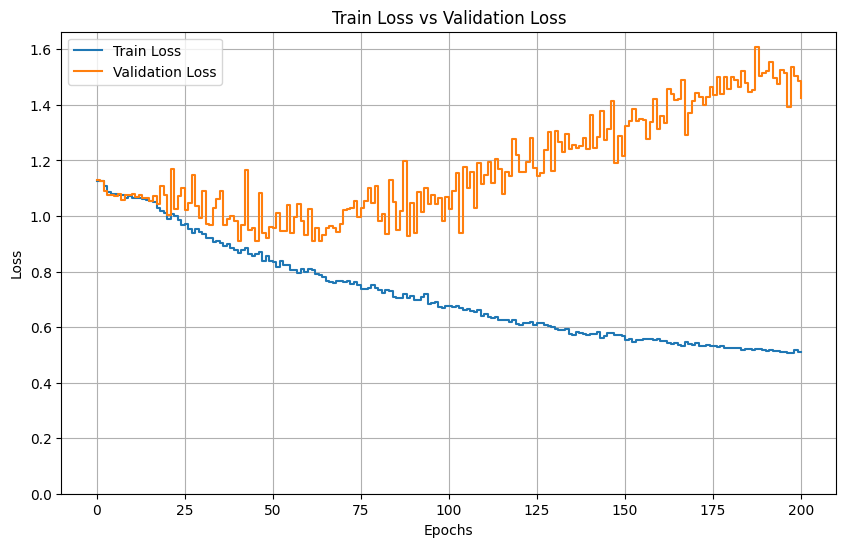

In [4]:
import matplotlib.pyplot as plt

# Assuming distinct_epochs_and_loss is your DataFrame containing 'epoch', 'train_loss_epoch', and 'val_loss'
plt.figure(figsize=(10, 6))

# Plot Train Loss
plt.plot(distinct_epochs_and_loss['epoch'], distinct_epochs_and_loss['train_loss_epoch'], label='Train Loss', linestyle='-', marker=None)

# Plot Validation Loss
plt.plot(distinct_epochs_and_loss['epoch'], distinct_epochs_and_loss['val_loss'], label='Validation Loss', linestyle='-', marker=None)

# Set plot labels and title
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs Validation Loss')
plt.legend()
plt.grid(True)
plt.ylim(0)  # Start y-axis from 0

# Show the plot
plt.show()


# Loss for each users val and train

C:\Users\Admin\AppData\Local\Temp\ipykernel_31880\2887747686.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', num_users).colors


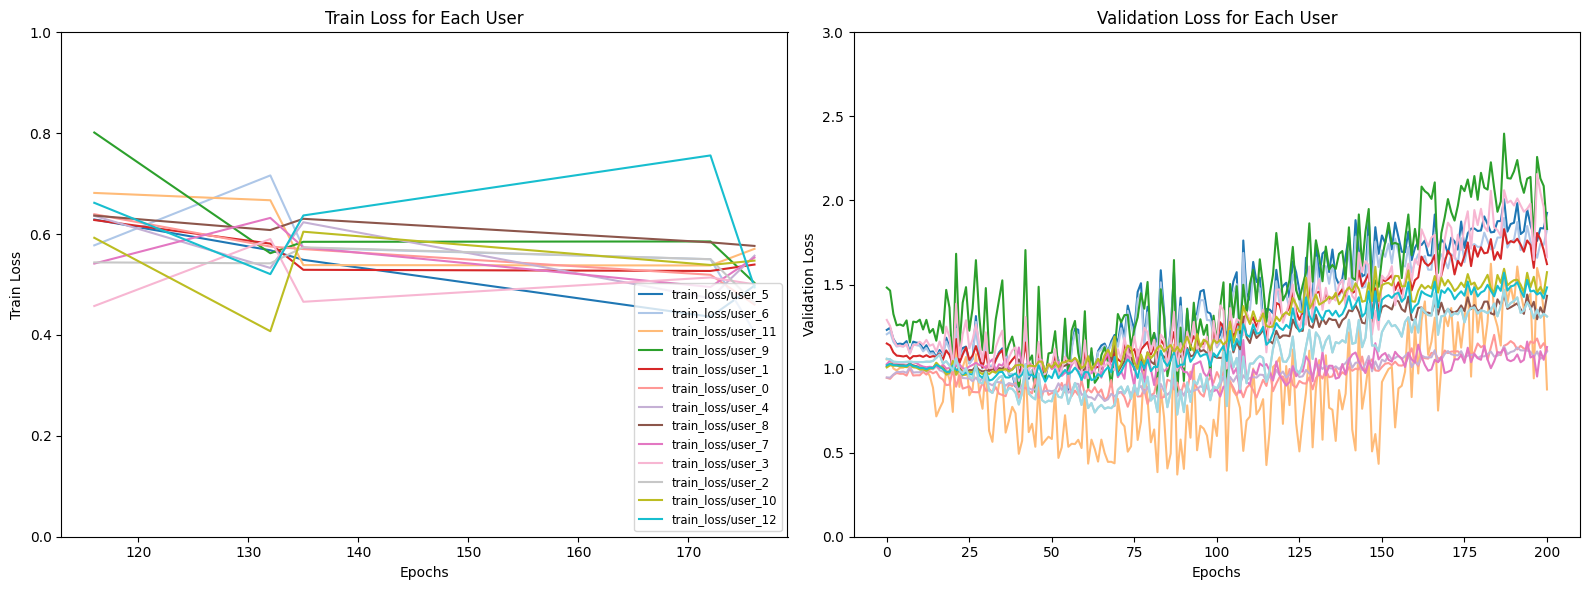

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Load the CSV file
metrics_data = pd.read_csv("D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/training_results/Transformer_V2_regressive/lightning_logs/version_16/metrics.csv")

# Extract user-specific train loss columns and validation loss columns
train_loss_columns = [col for col in metrics_data.columns if col.startswith('train_loss/user_')]
val_loss_columns = [col for col in metrics_data.columns if col.startswith('val_loss/user_')]

# Drop NaN values
train_loss_data = metrics_data[['epoch'] + train_loss_columns].dropna()
val_loss_data = metrics_data[['epoch'] + val_loss_columns].dropna()

# Generate unique colors for each user
num_users = max(len(train_loss_columns), len(val_loss_columns))
colors = cm.get_cmap('tab20', num_users).colors

# Create subplots WITHOUT shared y-axis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Removed sharey=True

# Set separate y-axis limits
axes[0].set_ylim(0, 1)   # Train loss range
axes[1].set_ylim(0, 3)  # Validation loss range

# Plot train loss with unique colors
for i, col in enumerate(train_loss_columns):
    axes[0].plot(train_loss_data['epoch'], train_loss_data[col], label=col, color=colors[i])
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Train Loss")
axes[0].set_title("Train Loss for Each User")
axes[0].legend(loc="lower right", fontsize='small')

# Plot validation loss with unique colors
for i, col in enumerate(val_loss_columns):
    axes[1].plot(val_loss_data['epoch'], val_loss_data[col], label=col, color=colors[i])
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Validation Loss")
axes[1].set_title("Validation Loss for Each User")


# Adjust layout for better visualization
plt.tight_layout()
plt.show()


# Precision for train and validation

In [10]:
# Check if required columns exist
required_columns = {'epoch', 'train_precision_epoch', 'val_precision', 'train_accuracy_epoch', 'val_accuracy'}
if required_columns.issubset(metrics.columns):
    # Filter the DataFrame for the required columns
    filtered_df = metrics[['epoch', 'train_precision_epoch', 'val_precision', 'train_accuracy_epoch', 'val_accuracy']].dropna()
    
    # Get the distinct (unique) rows
    distinct_epochs_and_precision = filtered_df.drop_duplicates()
    
    # Display the distinct rows
    print("Distinct values of 'epoch', 'train_precision_epoch', 'val_precision', 'train_accuracy_epoch', 'val_accuracy':\n", distinct_epochs_and_precision)
else:
    print("One or more required columns are missing from the DataFrame.")

Distinct values of 'epoch', 'train_precision_epoch', 'val_precision', 'train_accuracy_epoch', 'val_accuracy':
        epoch  train_precision_epoch  val_precision  train_accuracy_epoch  \
79       0.0               0.419559       0.478507              0.426559   
81       1.0               0.419559       0.478507              0.426559   
158      1.0               0.419559       0.461424              0.426559   
159      1.0               0.419713       0.461424              0.425111   
161      2.0               0.419713       0.461424              0.425111   
...      ...                    ...            ...                   ...   
15998  199.0               0.806697       0.516246              0.868775   
15999  199.0               0.807706       0.516246              0.869268   
16001  200.0               0.807706       0.516246              0.869268   
16078  200.0               0.807706       0.510198              0.869268   
16079  200.0               0.814296       0.510198   

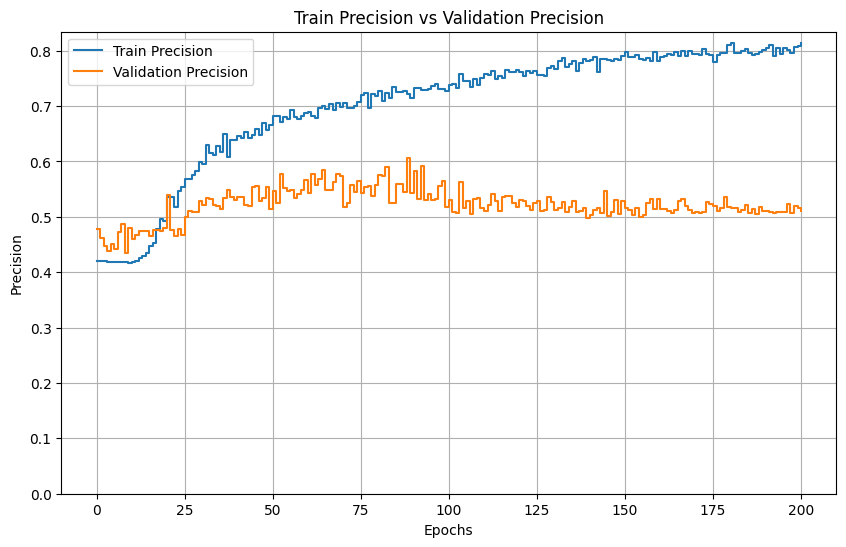

In [11]:
import matplotlib.pyplot as plt

# Assuming distinct_epochs_and_loss is your DataFrame containing 'epoch', 'train_precision_epoch', and 'val_precision'
plt.figure(figsize=(10, 6))

# Plot Train Loss
plt.plot(distinct_epochs_and_precision['epoch'], distinct_epochs_and_precision['train_precision_epoch'], label='Train Precision', linestyle='-', marker=None)

# Plot Validation Loss
plt.plot(distinct_epochs_and_precision['epoch'], distinct_epochs_and_precision['val_precision'], label='Validation Precision', linestyle='-', marker=None)

# Set plot labels and title
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.title('Train Precision vs Validation Precision')
plt.legend()
plt.grid(True)
plt.ylim(0)  # Start y-axis from 0

# Show the plot
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_31880\3766688083.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', num_users).colors


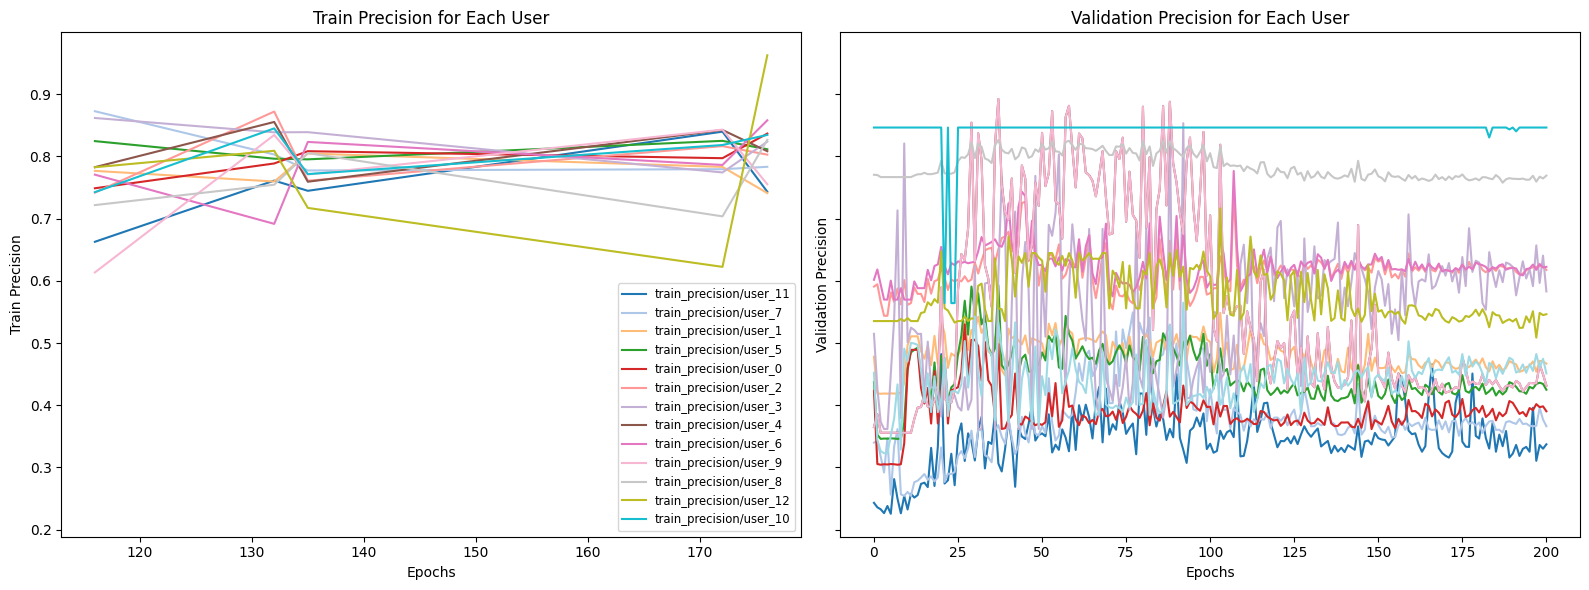

In [13]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Load the CSV file
metrics_data = pd.read_csv("D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/training_results/Transformer_V2_regressive/lightning_logs/version_16/metrics.csv")


# Extract user-specific train precision columns and validation precision columns
train_precision_columns = [col for col in metrics_data.columns if col.startswith('train_precision/user_')]
val_precision_columns = [col for col in metrics_data.columns if col.startswith('val_precision/user_')]

# Drop NaN values
train_precision_data = metrics_data[['epoch'] + train_precision_columns].dropna()
val_precision_data = metrics_data[['epoch'] + val_precision_columns].dropna()

# Generate unique colors for each user
num_users = max(len(train_precision_columns), len(val_precision_columns))
colors = cm.get_cmap('tab20', num_users).colors

# Create subplots beside each other
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot train precision with unique colors
for i, col in enumerate(train_precision_columns):
    axes[0].plot(train_precision_data['epoch'], train_precision_data[col], label=col, color=colors[i])
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Train Precision")
axes[0].set_title("Train Precision for Each User")
axes[0].legend(loc="lower right", fontsize='small')

# Plot validation precision with unique colors
for i, col in enumerate(val_precision_columns):
    axes[1].plot(val_precision_data['epoch'], val_precision_data[col], label=col, color=colors[i])
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Validation Precision")
axes[1].set_title("Validation Precision for Each User")


# Adjust layout for better visualization
plt.tight_layout()
plt.show()



# Accuracy for Train and Validation

In [14]:
# Check if required columns exist
required_columns = {'epoch', 'train_accuracy_epoch', 'val_accuracy'}
if required_columns.issubset(metrics.columns):
    # Filter the DataFrame for the required columns
    filtered_df = metrics[['epoch', 'train_accuracy_epoch', 'val_accuracy']].dropna()
    
    # Get the distinct (unique) rows
    distinct_epochs_and_accuracy = filtered_df.drop_duplicates()
    
    # Display the distinct rows
    print("Distinct values of 'epoch', 'train_accuracy_epoch', and 'val_accuracy':\n", distinct_epochs_and_accuracy)
else:
    print("One or more required columns are missing from the DataFrame.")

Distinct values of 'epoch', 'train_accuracy_epoch', and 'val_accuracy':
        epoch  train_accuracy_epoch  val_accuracy
79       0.0              0.426559      0.550346
81       1.0              0.426559      0.550346
158      1.0              0.426559      0.531979
159      1.0              0.425111      0.531979
161      2.0              0.425111      0.531979
...      ...                   ...           ...
15998  199.0              0.868775      0.631050
15999  199.0              0.869268      0.631050
16001  200.0              0.869268      0.631050
16078  200.0              0.869268      0.630726
16079  200.0              0.870593      0.630726

[601 rows x 3 columns]


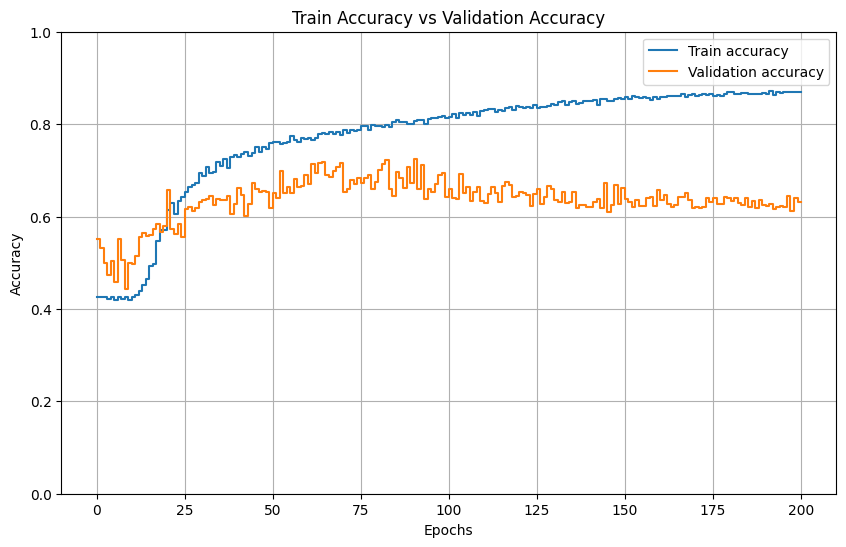

In [16]:
import matplotlib.pyplot as plt

# Assuming distinct_epochs_and_accuracy is your DataFrame containing 'epoch', 'train_accuracy_epoch', and 'val_accuracy'
plt.figure(figsize=(10, 6))

# Plot Train Accuracy
plt.plot(distinct_epochs_and_accuracy['epoch'], distinct_epochs_and_accuracy['train_accuracy_epoch'], label='Train accuracy', linestyle='-', marker=None)

# Plot Validation Accuracy
plt.plot(distinct_epochs_and_accuracy['epoch'], distinct_epochs_and_accuracy['val_accuracy'], label='Validation accuracy', linestyle='-', marker=None)

# Set plot labels and title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train Accuracy vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim(0,1)  # Start y-axis from 0

# Show the plot
plt.show()


# Calculate using metrics.csv file 

In [20]:
import pandas as pd

# Load the metrics CSV file
file_path = "D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/training_results/Transformer_V2_regressive/lightning_logs/version_6_combine/metrics.csv"
metrics_data = pd.read_csv(file_path)

# Extract relevant columns
columns_of_interest = ['epoch', 'train_accuracy_epoch', 'val_accuracy']
filtered_metrics = metrics_data[columns_of_interest].dropna()

# Ensure there are valid rows
if not filtered_metrics.empty:
    # Get the final epoch's values
    final_metrics = filtered_metrics.iloc[-1]

    # Print final accuracy
    print("\n📊 Final Accuracy Results 📊")
    print(f"🟢 Train Accuracy: {final_metrics['train_accuracy_epoch'] * 100:.2f}%")
    print(f"🔵 Validation Accuracy: {final_metrics['val_accuracy'] * 100:.2f}%")

else:
    print("⚠️ No valid data found in metrics.csv. Please check the file content.")


⚠️ No valid data found in metrics.csv. Please check the file content.
